In [ ]:
!pip install gwpy scipy matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from gwpy.timeseries import TimeSeries
from scipy.signal import welch
from scipy.signal import (
    butter,
    filtfilt,
    detrend,
    iirnotch,
    welch
)

import h5py

In [ ]:
gps = 1126259462        # GW150914
duration = 32           # seconds

strain = TimeSeries.fetch_open_data(
    "H1",
    gps-duration//2,
    gps+duration//2
)

fs = int(strain.sample_rate.value)
N = len(strain)
T = 1/fs
time = np.arange(N)/fs


print("Sampling Frequency :", fs)
print("Number of Samples :", len(strain))

Sampling Frequency : 4096
Number of Samples : 131072


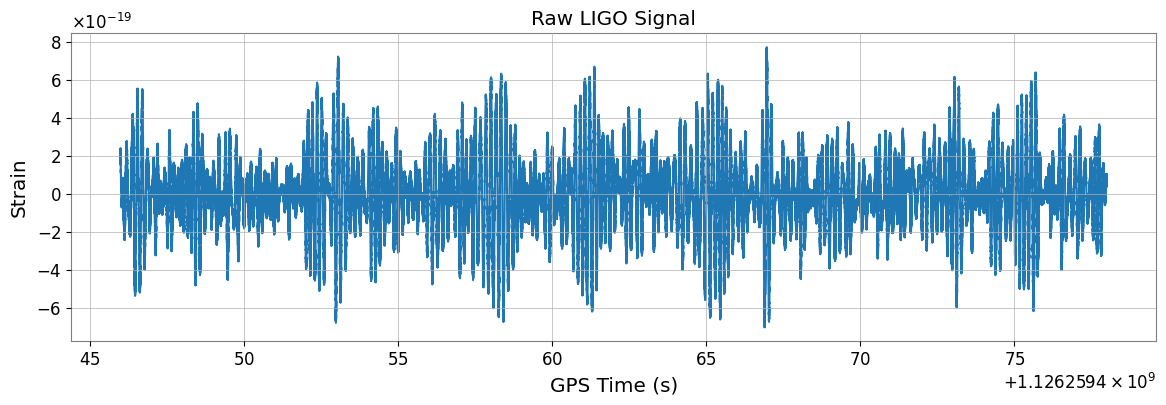

In [ ]:
plt.figure(figsize=(14,4))   # plotting raw signal

plt.plot(strain.times.value, strain.value)

plt.xlabel("GPS Time (s)")
plt.ylabel("Strain")
plt.title("Raw LIGO Signal")

plt.grid(True)

plt.show()

In [ ]:
fft_signal = fft(strain)

In [ ]:
frequency = fftfreq(N, d=T)

In [ ]:
positive = frequency >= 0

frequency = frequency[positive]

fft_signal = fft_signal[positive]

In [ ]:
magnitude = np.abs(fft_signal)

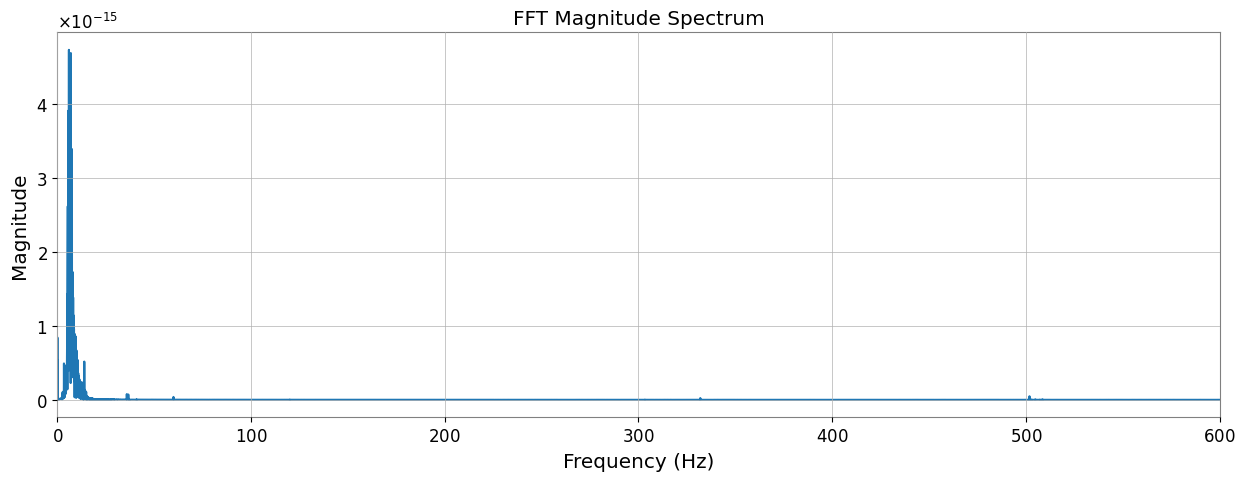

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(frequency, magnitude)

plt.xlim(0,600)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.title("FFT Magnitude Spectrum")

plt.grid(True)

plt.show()

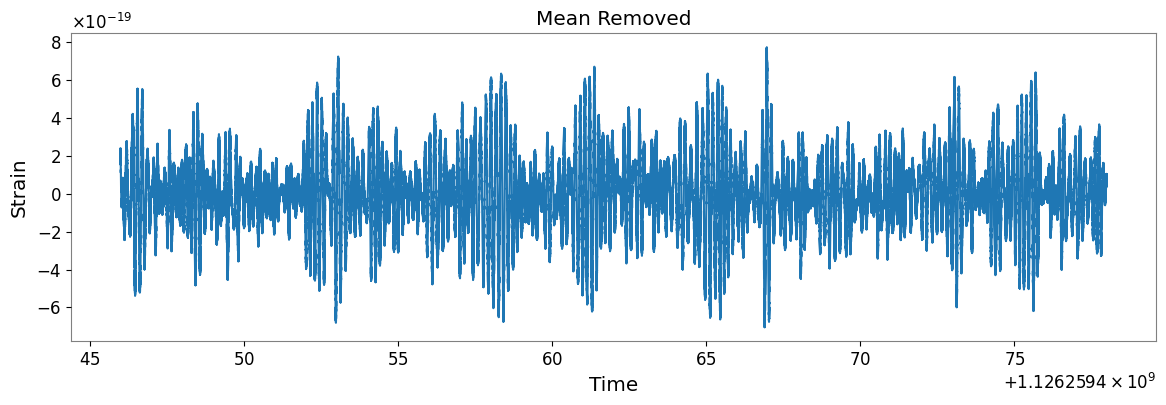

In [ ]:
strain_zero = strain.value - np.mean(strain.value) # removing mean

plt.figure(figsize=(14,4))
plt.plot(strain.times.value, strain_zero)

plt.title("Mean Removed")
plt.xlabel("Time")
plt.ylabel("Strain")

plt.grid()

plt.show()

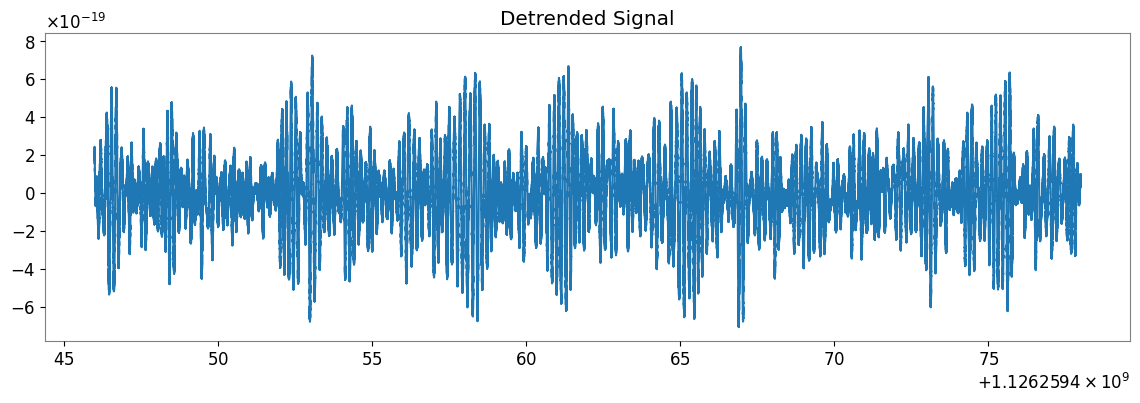

In [ ]:
from scipy.signal import detrend  #detrend signal

strain_detrend = detrend(strain_zero)

plt.figure(figsize=(14,4))

plt.plot(strain.times.value, strain_detrend)

plt.title("Detrended Signal")

plt.grid()

plt.show()

In [ ]:
lowcut = 20
highcut = 400

order = 4

nyquist = fs/2

low = lowcut/nyquist
high = highcut/nyquist

b, a = butter(
    order,
    [low, high],
    btype="band"
)

In [ ]:
bandpassed = filtfilt(
    b,
    a,
    strain_detrend
)


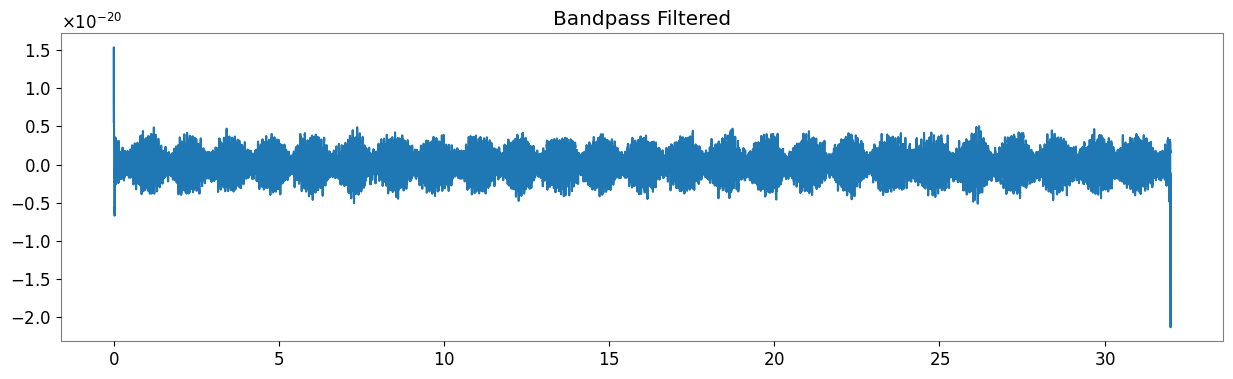

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(time, bandpassed)

plt.title("Bandpass Filtered")

plt.grid()

plt.show()

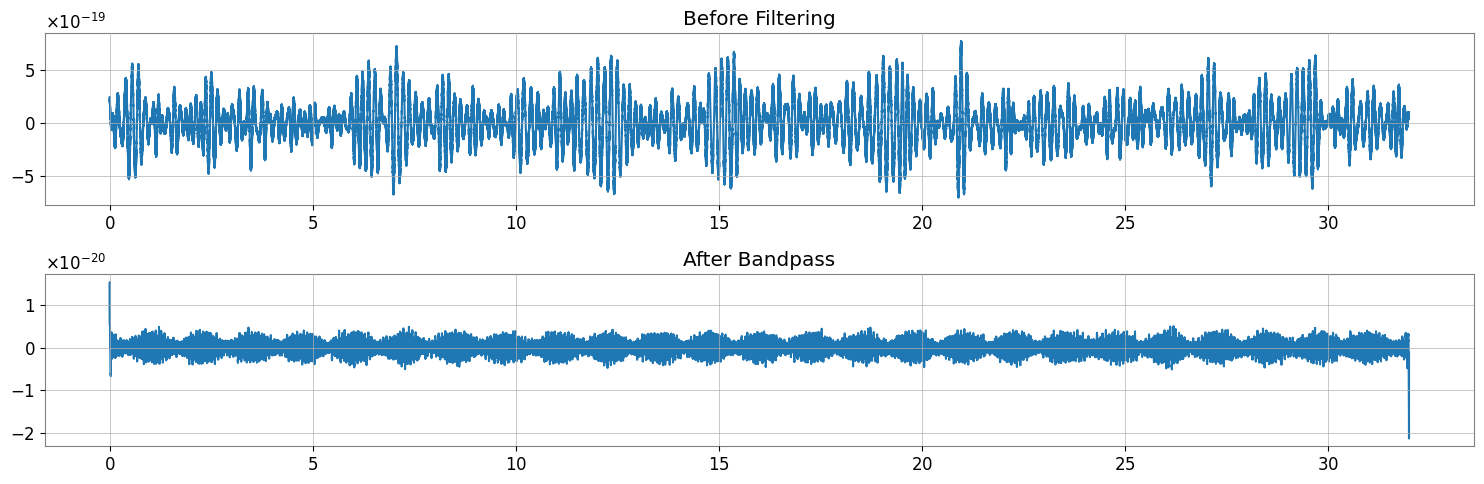

In [ ]:
plt.figure(figsize=(15,5))    # comparing

plt.subplot(211)
plt.plot(time, strain_detrend)
plt.title("Before Filtering")

plt.subplot(212)
plt.plot(time, bandpassed)
plt.title("After Bandpass")

plt.tight_layout()

plt.show()

In [ ]:
notch = 60

Q = 30

b_notch, a_notch = iirnotch(
    notch,
    Q,
    fs
)

In [ ]:
notched = filtfilt(
    b_notch,
    a_notch,
    bandpassed
)

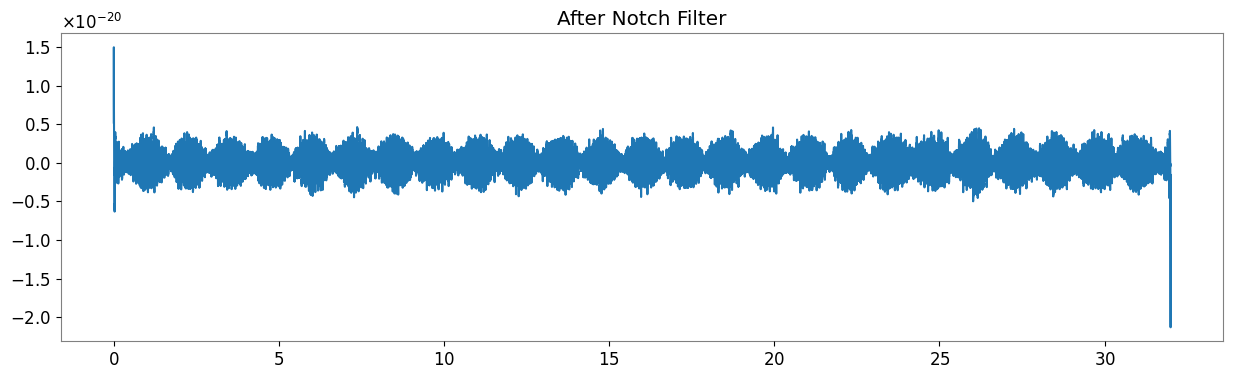

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(time, notched)

plt.title("After Notch Filter")

plt.grid()

plt.show()

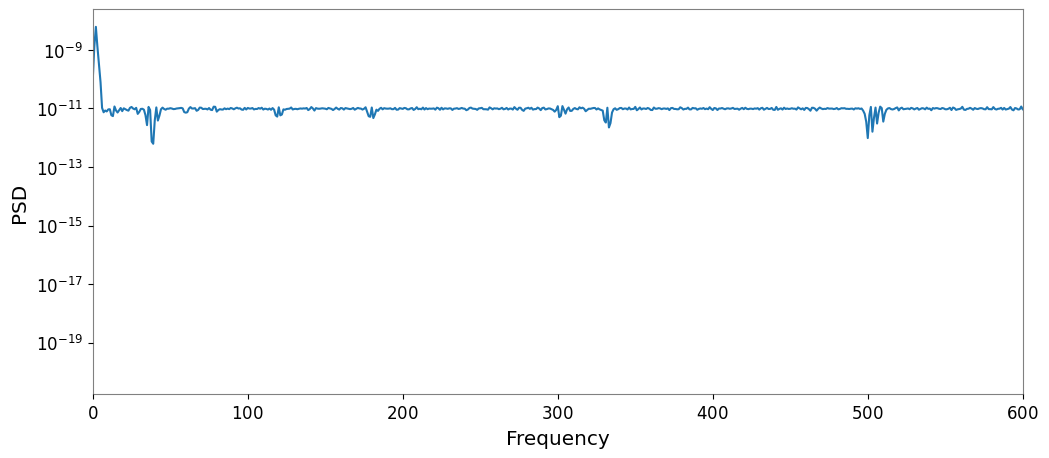

In [ ]:
freq, psd = welch(
    signal,
    fs=4096,
    window="hann",
    nperseg=4096,
    noverlap=2048,
    scaling="density"
)
plt.figure(figsize=(12,5))

plt.semilogy(freq, psd)

plt.xlim(0,600)

plt.xlabel("Frequency")

plt.ylabel("PSD")

plt.grid()

plt.show()

In [ ]:
print(psd_interp.min())
print(psd_interp.max())

4.1952924829308604e-23
0.0019479328564440028


In [ ]:
fft_signal = np.fft.rfft(notched)

In [ ]:
fft_freq = np.fft.rfftfreq(
    len(notched),
    1/fs
)

In [ ]:
psd_interp = np.interp(
    fft_freq,
    freq,
    psd
)

In [ ]:
# white_fft = fft_signal / np.sqrt(psd_interp)
eps = np.max(psd_interp) * 1e-12

white_fft = fft_signal / np.sqrt(psd_interp + eps)

whitened = np.fft.irfft(
    white_fft,
    n=len(notched)
)

In [ ]:
whitened = whitened/np.std(whitened)

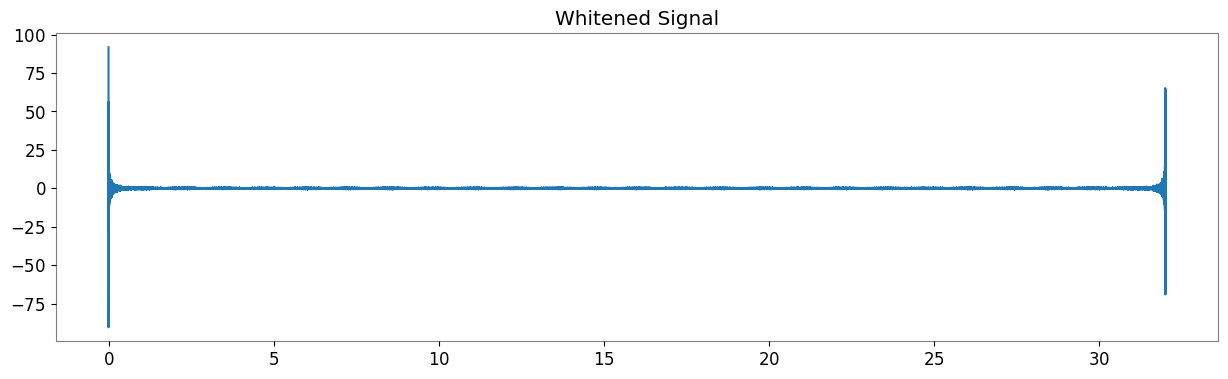

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(time, whitened)

plt.title("Whitened Signal")

plt.grid()

plt.show()

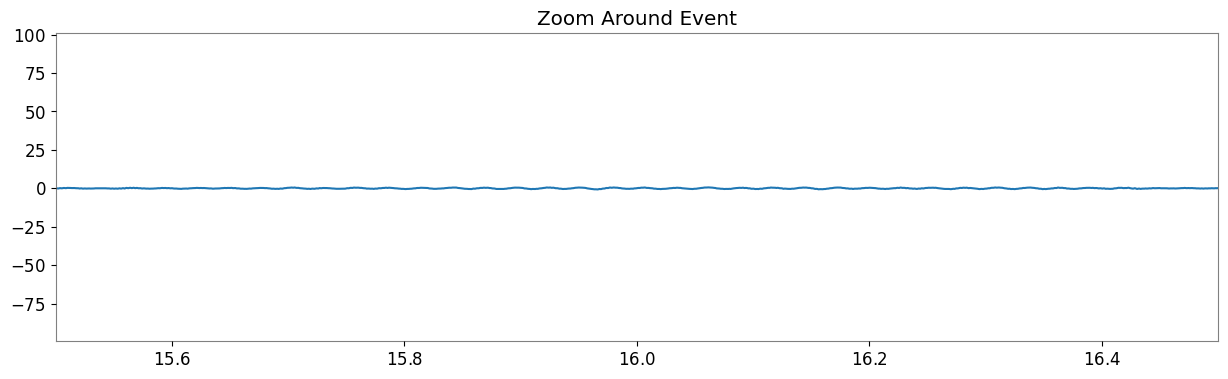

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(time, whitened)

plt.xlim(15.5,16.5)

plt.grid()

plt.title("Zoom Around Event")

plt.show()

In [ ]:
print(freq.shape)
print(psd.shape)
print(fft_freq.shape)

print(freq[0], freq[-1])
print(fft_freq[0], fft_freq[-1])

(2049,)
(2049,)
(65537,)
0.0 2048.0
0.0 2048.0


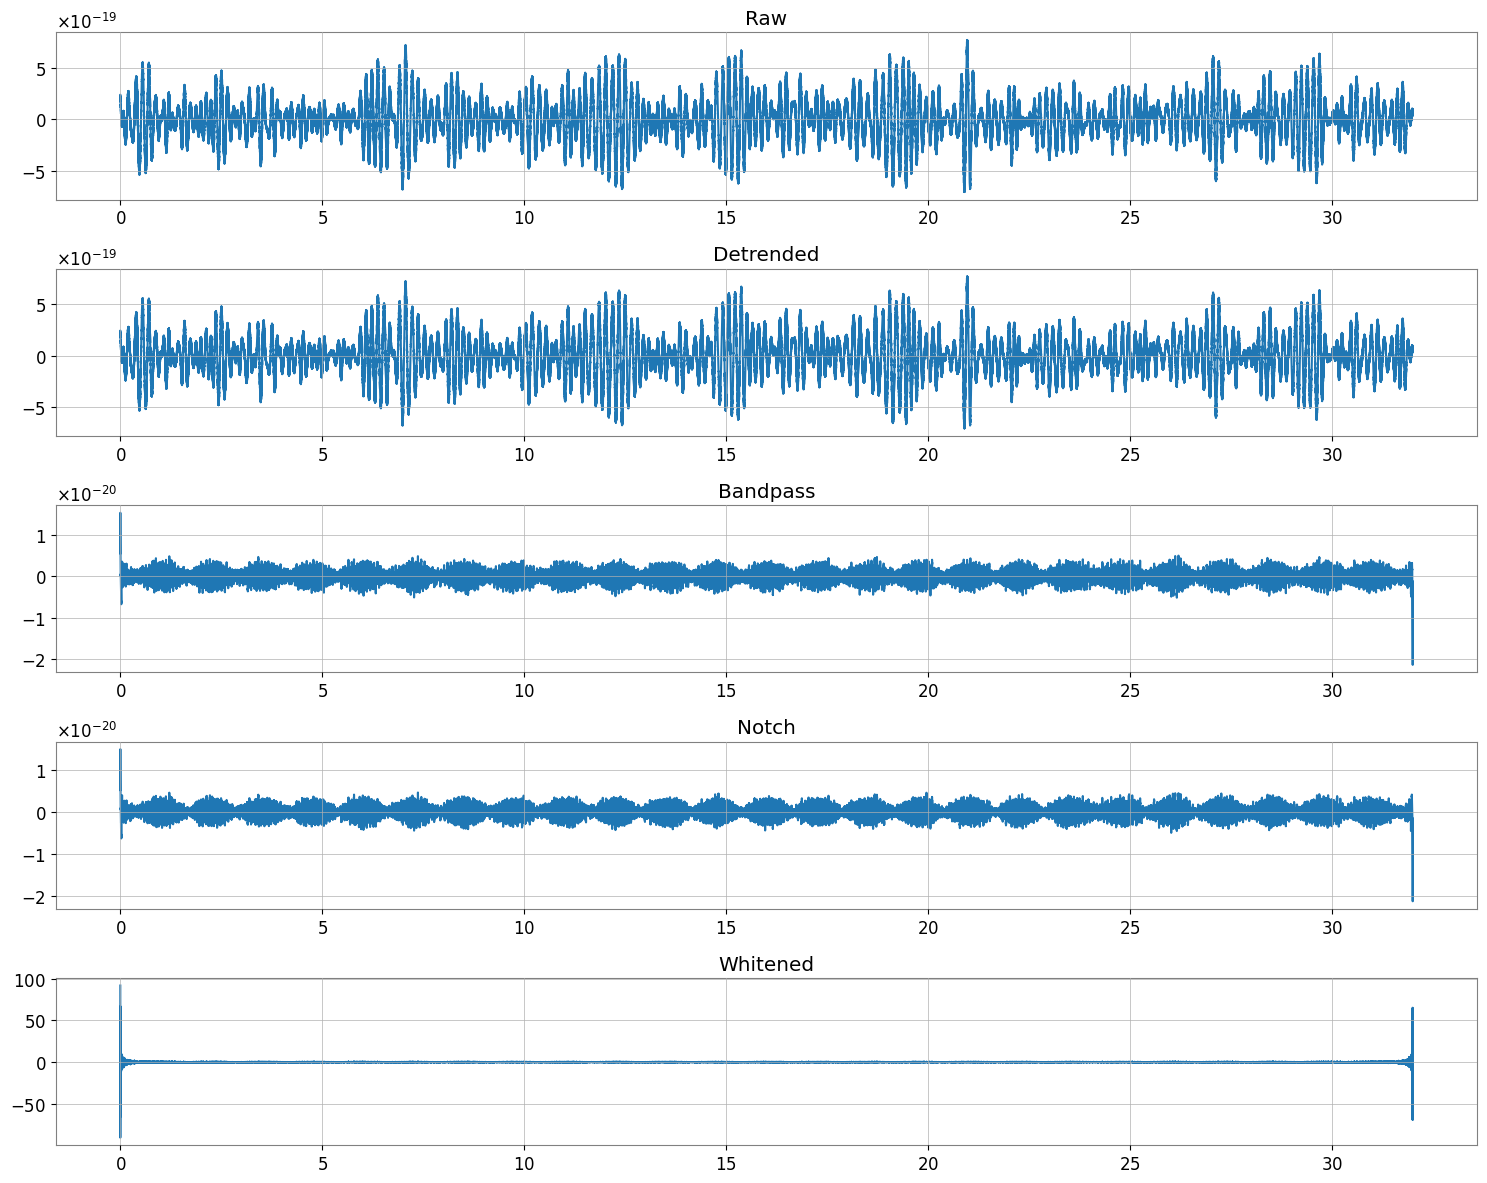

In [ ]:
plt.figure(figsize=(15,12))

plt.subplot(5,1,1)
plt.plot(time, strain)
plt.title("Raw")

plt.subplot(5,1,2)
plt.plot(time, strain_detrend)
plt.title("Detrended")

plt.subplot(5,1,3)
plt.plot(time, bandpassed)
plt.title("Bandpass")

plt.subplot(5,1,4)
plt.plot(time, notched)
plt.title("Notch")

plt.subplot(5,1,5)
plt.plot(time, whitened)
plt.title("Whitened")

plt.tight_layout()

plt.show()

In [ ]:
!pip install PyWavelets

In [ ]:
import pywt
from scipy.signal import stft
from scipy.signal import spectrogram

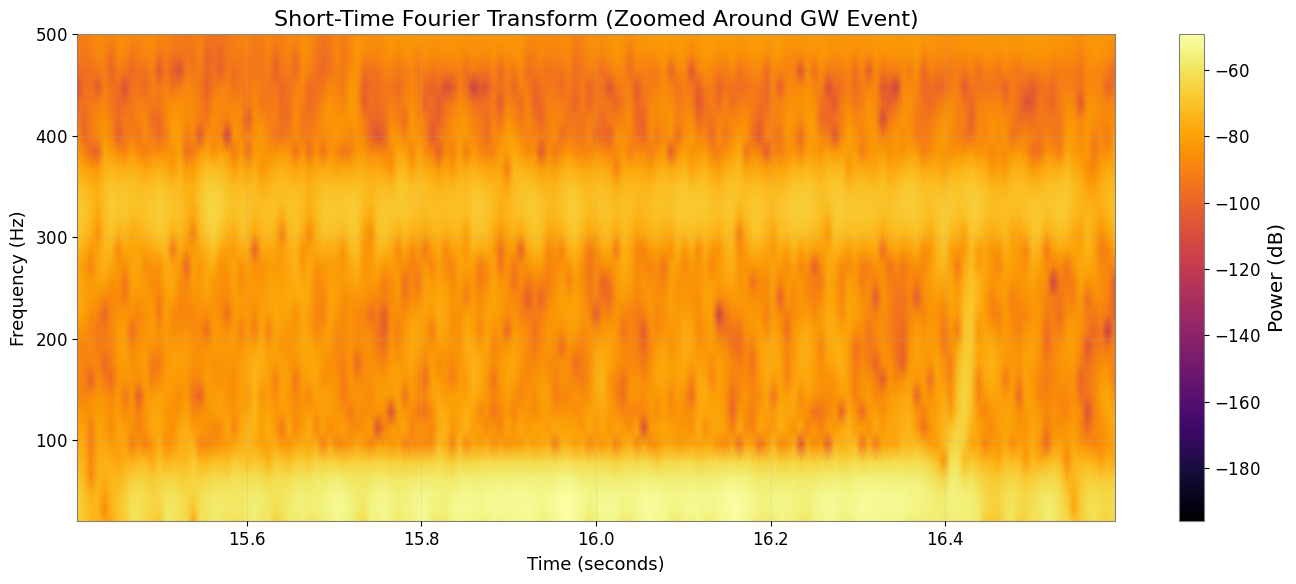

In [ ]:
from scipy.signal import stft
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
fs = 4096                     # Sampling frequency
event_time = 16               # Event location (middle of 32 sec data)
zoom = 0.6                    # Show ±0.6 seconds around event

# -----------------------------
# NORMALIZE SIGNAL
# -----------------------------
signal = whitened.copy()
signal = signal / np.max(np.abs(signal))

# -----------------------------
# STFT
# -----------------------------
f, t, Zxx = stft(
    signal,
    fs=fs,
    window='hann',
    nperseg=128,
    noverlap=96,
    nfft=256,
    boundary=None,
    padded=False
)

# -----------------------------
# Convert to dB
# -----------------------------
power_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

# -----------------------------
# Zoom around GW event
# -----------------------------
mask = (t >= event_time - zoom) & (t <= event_time + zoom)

t_zoom = t[mask]
power_zoom = power_db[:, mask]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(14,6))

plt.pcolormesh(
    t_zoom,
    f,
    power_zoom,
    shading='gouraud',
    cmap='inferno'
)

plt.title("Short-Time Fourier Transform (Zoomed Around GW Event)", fontsize=16)

plt.xlabel("Time (seconds)", fontsize=13)
plt.ylabel("Frequency (Hz)", fontsize=13)

plt.ylim(20,500)

plt.colorbar(label="Power (dB)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
f, t, Zxx = stft(
    whitened,
    fs=fs,
    window='hann',
    nperseg=256,
    noverlap=128
)
magnitude = np.abs(Zxx)

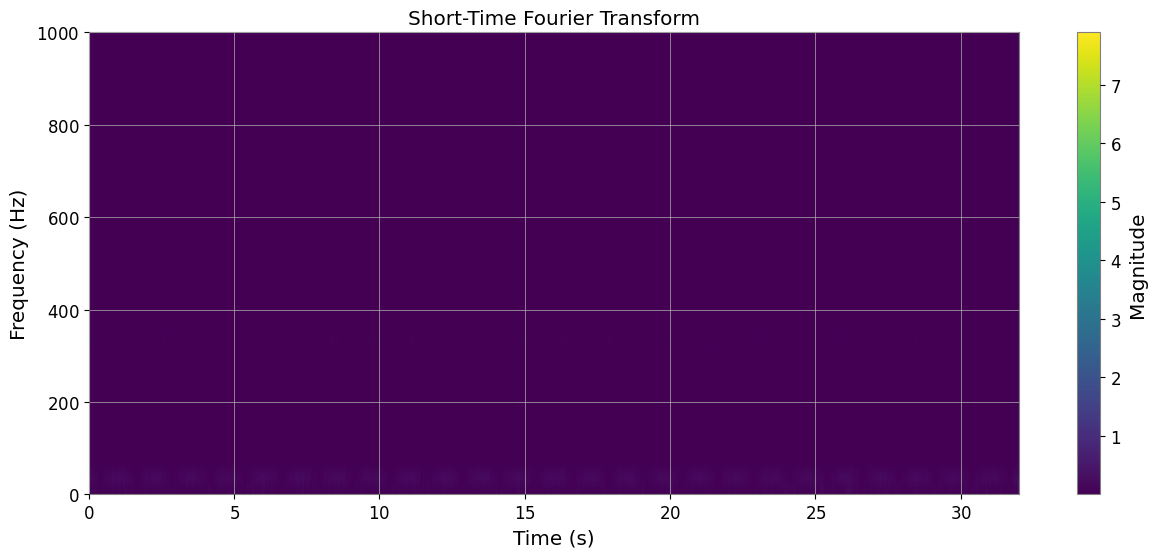

In [ ]:
plt.figure(figsize=(15,6))

plt.pcolormesh(
    t,
    f,
    magnitude,
    shading='gouraud'
)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")

plt.ylim(0,1000)

plt.colorbar(label="Magnitude")

plt.title("Short-Time Fourier Transform")

plt.show()

In [ ]:
f_spec, t_spec, Sxx = spectrogram(
    whitened,
    fs=fs,
    window='hann',
    nperseg=256,
    noverlap=128
)

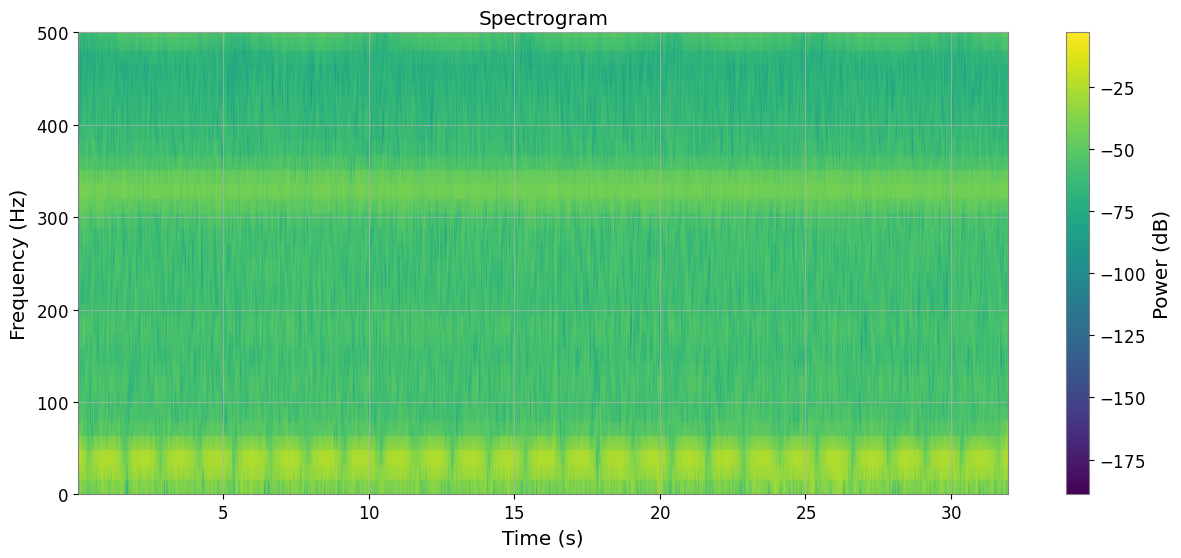

In [ ]:
plt.figure(figsize=(15,6))

plt.pcolormesh(
    t_spec,
    f_spec,
    10*np.log10(Sxx),
    shading='gouraud'
)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")

plt.ylim(0,500)

plt.colorbar(label="Power (dB)")

plt.title("Spectrogram")

plt.show()

In [ ]:
scales = np.arange(1, 256)

coefficients, frequencies = pywt.cwt(
    whitened,
    scales,
    'morl',
    sampling_period=1/fs
)

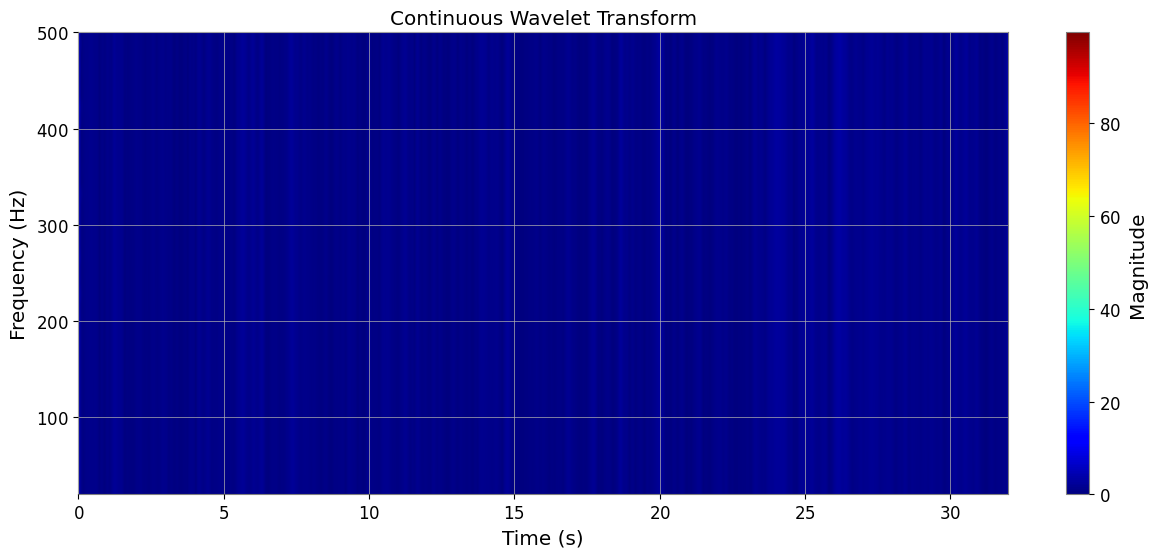

In [ ]:
plt.figure(figsize=(15,6))

plt.imshow(
    np.abs(coefficients),
    extent=[time[0], time[-1], frequencies[-1], frequencies[0]],
    aspect='auto',
    cmap='jet'
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.ylim(20,500)

plt.colorbar(label="Magnitude")

plt.title("Continuous Wavelet Transform")

plt.show()

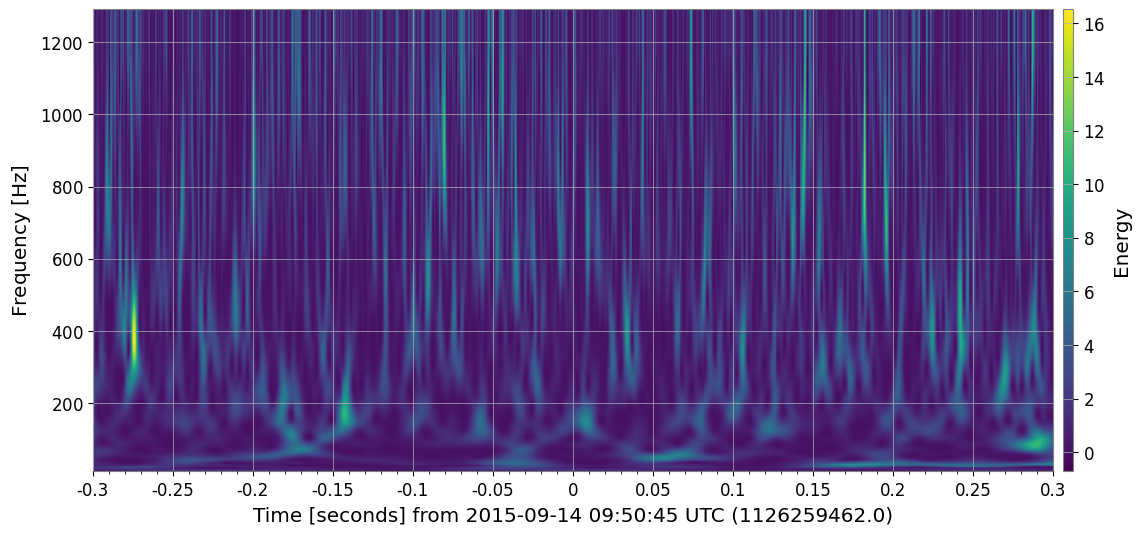

In [ ]:
q = strain.q_transform(
    outseg=(gps-0.3, gps+0.3)
)

plot = q.plot()

plot.colorbar(label="Energy")

plot.show()

In [ ]:

# DATASET GENERATION


!pip install pycbc pandas tqdm -q

import os
import random
import numpy as np
import pandas as pd

from tqdm import tqdm
from pycbc.waveform import get_td_waveform


# USE YOUR WHITENED SIGNAL


# Replace this if your variable has another name
noise = whitened.copy()

# Normalize
noise = (noise - np.mean(noise)) / np.std(noise)

fs = 4096

window_size = fs * 2          # 2-second samples


# CREATE FOLDERS

folders = [

    "dataset/train/signal",
    "dataset/train/noise",

    "dataset/validation/signal",
    "dataset/validation/noise",

    "dataset/test/signal",
    "dataset/test/noise"

]

for folder in folders:
    os.makedirs(folder, exist_ok=True)


# DATASET SIZE


TRAIN = 1000
VALID = 200
TEST = 200

# METADATA


metadata = []

# FUNCTION TO SAVE SAMPLE

def save_sample(folder, filename, sample):

    np.save(
        os.path.join(folder, filename),
        sample
    )


# FUNCTION TO GENERATE SIGNAL


def generate_signal():

    mass1 = random.uniform(10,80)
    mass2 = random.uniform(10,80)

    hp, hc = get_td_waveform(

        approximant="SEOBNRv4",

        mass1=mass1,

        mass2=mass2,

        delta_t=1/fs,

        f_lower=20

    )

    signal = hp.numpy()

    signal = signal / np.max(np.abs(signal))

    amplitude = random.uniform(0.3,1.0)

    signal *= amplitude

    return signal, mass1, mass2, amplitude


# FUNCTION TO BUILD DATASET

def build_dataset(num_samples, split):

    for i in tqdm(range(num_samples), desc=split):

        # ------------------------
        # NOISE SAMPLE
        # ------------------------

        start = random.randint(
            0,
            len(noise)-window_size
        )

        noise_sample = noise[
            start:start+window_size
        ].copy()

        # Save Noise

        save_sample(

            f"dataset/{split}/noise",

            f"noise_{i}.npy",

            noise_sample

        )

        metadata.append({

            "split":split,
            "filename":f"noise_{i}.npy",
            "label":0,
            "mass1":None,
            "mass2":None,
            "amplitude":None,
            "injection_index":None

        })


        # SIGNAL SAMPLE


        signal_sample = noise_sample.copy()

        waveform, m1, m2, amp = generate_signal()

        inject_index = random.randint(
            1000,
            window_size-1000
        )

        waveform = waveform[
            :window_size-inject_index
        ]

        signal_sample[
            inject_index:
            inject_index+len(waveform)
        ] += waveform

        save_sample(

            f"dataset/{split}/signal",

            f"signal_{i}.npy",

            signal_sample

        )

        metadata.append({

            "split":split,
            "filename":f"signal_{i}.npy",
            "label":1,
            "mass1":round(m1,2),
            "mass2":round(m2,2),
            "amplitude":round(amp,3),
            "injection_index":inject_index

        })

# BUILD DATASET


build_dataset(TRAIN, "train")

build_dataset(VALID, "validation")

build_dataset(TEST, "test")


# SAVE METADATA


metadata = pd.DataFrame(metadata)

metadata.to_csv(
    "dataset/metadata.csv",
    index=False
)

print("\nDataset Created Successfully!")

print(metadata.head())

test: 100%|██████████| 200/200 [01:54<00:00,  1.74it/s]


Dataset Created Successfully!
   split      filename  label  mass1  mass2  amplitude  injection_index
0  train   noise_0.npy      0    NaN    NaN        NaN              NaN
1  train  signal_0.npy      1  64.84  56.53      0.923           6481.0
2  train   noise_1.npy      0    NaN    NaN        NaN              NaN
3  train  signal_1.npy      1  51.75  70.76      0.579           1001.0
4  train   noise_2.npy      0    NaN    NaN        NaN              NaN
